In [64]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [65]:
df = pd.read_csv('../__datasets__/train.csv', usecols=['Age', 'Fare', 'Survived'])
df.sample(5)

,Survived,Age,Fare
346,1,40.0,13.0000
402,0,21.0,9.8250
12,0,20.0,8.0500
43,1,3.0,41.5792
697,1,NaN,7.7333


In [66]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [67]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
X_train['Age_Imputed'] = X_train['Age']
X_test['Age_Imputed'] = X_test['Age']

In [70]:
X_train['Age_Imputed'][X_train['Age_Imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_Imputed'][X_test['Age_Imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [71]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
# Age se null values hta kr random values lo jitni missing thi or unki values daal do missing walo me

array([19.  , 34.  , 26.  , 35.  , 34.  , 55.  , 28.  , 40.  , 29.  ,
       15.  , 30.  , 41.  , 42.  , 18.  , 11.  ,  4.  , 28.5 , 40.  ,
       19.  , 22.  , 40.  ,  7.  ,  4.  ,  2.  , 21.  , 29.  , 22.  ,
       19.  , 20.  , 34.  , 31.  ,  4.  , 42.  , 24.  ,  1.  , 32.  ,
       19.  , 23.  , 20.  ,  2.  , 32.  , 36.  , 22.  , 25.  , 34.  ,
        8.  , 21.  , 20.  , 24.  , 33.  , 60.  , 70.5 , 32.  , 25.  ,
       39.  , 25.  ,  1.  , 40.5 , 34.  , 23.  ,  0.42, 61.  ,  9.  ,
       42.  , 19.  , 24.  , 48.  , 30.  , 27.  , 34.  , 34.  , 33.  ,
       22.  , 27.  , 21.  , 37.  , 62.  , 33.  , 25.  , 49.  , 51.  ,
       38.  , 59.  , 19.  , 36.  , 43.  , 18.  , 16.  , 30.  , 14.  ,
       25.  , 14.  , 24.  , 21.  , 40.  , 26.  , 56.  ,  0.75, 44.  ,
       44.  , 33.  , 45.  , 35.  , 58.  , 18.  , 28.  , 22.  , 42.  ,
       46.  , 20.  , 24.  , 21.  , 19.  , 18.  , 31.  , 32.5 , 52.  ,
       45.  ,  8.  , 27.  , 74.  , 32.  , 36.  , 27.  , 35.  , 54.  ,
       35.  , 23.  ,

In [72]:
X_train['Age'].isnull().sum()    # itni values pahele missing thi

140

In [73]:
X_train['Age_Imputed'].isnull().sum()    # now there is no missing value
X_test['Age_Imputed'].isnull().sum()

0

In [74]:
X_train.sample(5)

,Age,Fare,Age_Imputed
418,30.0,13.0000,30.0
329,16.0,57.9792,16.0
732,NaN,0.0000,30.0
267,25.0,7.7750,25.0
829,62.0,80.0000,62.0


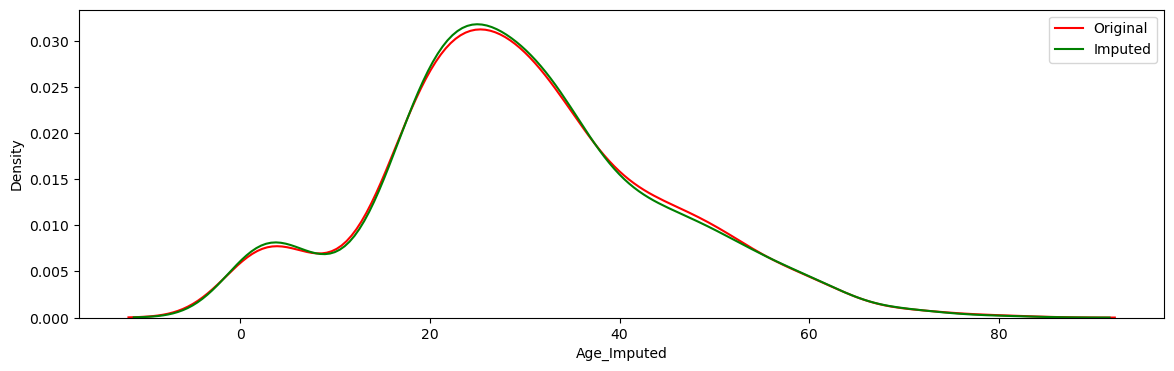

In [75]:
plt.figure(figsize=(14,4))
sns.distplot(X_train['Age'], label='Original', hist = False, color='red')
sns.distplot(X_train['Age_Imputed'], label='Imputed', hist = False, color='green')
plt.legend()
plt.show()

In [76]:
# Difference in variance
print('Original variable variance : ', X_train['Age'].var())
print('Imputed variable variance : ', X_train['Age_Imputed'].var())

Original variable variance :  210.2517072477438
Imputed variable variance :  209.01842924113944


In [77]:
X_train[['Fare', 'Age', 'Age_Imputed']].cov()

,Fare,Age,Age_Imputed
Fare,2700.831981,71.580633,50.200926
Age,71.580633,210.251707,210.251707
Age_Imputed,50.200926,210.251707,209.018429


<Axes: >

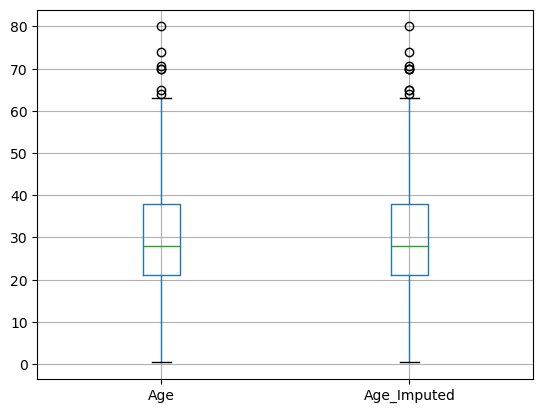

In [78]:
X_train[['Age', 'Age_Imputed']].boxplot()

In [79]:
# don't generate new random value always try to fix this value for same fair again and again
sample_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

NameError: name 'observation' is not defined

In [80]:
data = pd.read_csv('../__datasets__/housingPrices.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
data.sample(3)

,FireplaceQu,GarageQual,SalePrice
326,Gd,TA,324000
1300,TA,TA,225000
305,NaN,TA,305900


In [81]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [82]:
X = data
y = data['SalePrice']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
X_train['GarageQual_Imputed'] = X_train['GarageQual']
X_test['GarageQual_Imputed'] = X_train['GarageQual']

X_train['FireplaceQu_Imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_Imputed'] = X_train['FireplaceQu']

In [85]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_Imputed'].value_counts() / len(X_train)
    ],
    axis = 1
)
temp.columns = ['Original', 'Imputed']

In [86]:
temp

,Original,Imputed
TA,0.951087,0.898973
Fa,0.032609,0.030822
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [87]:
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_Imputed'].value_counts() / len(X_train)
    ],
    axis = 1
)
temp.columns = ['Original', 'Imputed']

In [88]:
temp

,Original,Imputed
Gd,0.491143,0.261130
TA,0.405797,0.215753
Fa,0.043478,0.023116
Ex,0.033816,0.017979
Po,0.025765,0.013699


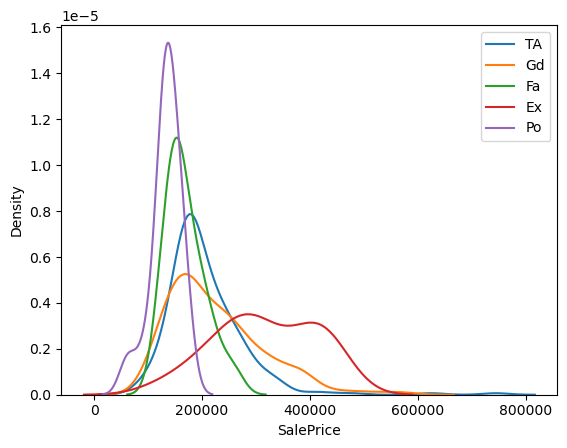

In [89]:
for cat in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu']==cat]['SalePrice'], hist=False, label=cat)
plt.legend()
plt.show()

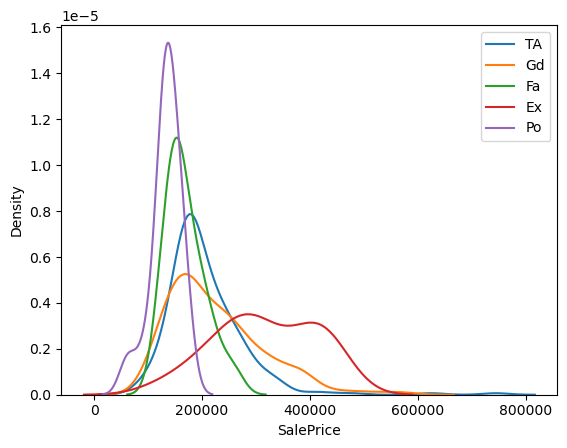

In [90]:
for cat in X_train['FireplaceQu_Imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_Imputed']==cat]['SalePrice'], hist=False, label=cat)
plt.legend()
plt.show()

## 2. Missing Indicator

In [91]:
df.sample(4)

,Survived,Age,Fare
368,1,NaN,7.7500
25,1,38.0,31.3875
608,1,22.0,41.5792
306,1,NaN,110.8833


In [92]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
X_train.sample(4)

,Age,Fare
862,48.0,25.9292
505,18.0,108.9000
115,21.0,7.9250
838,32.0,56.4958


In [95]:
from sklearn.impute import SimpleImputer

In [96]:
si = SimpleImputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [100]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_trf, y_train)
y_pred = clf.predict(X_test_trf)

from sklearn.metrics import accuracy_score
print('Acc_score : ', accuracy_score(y_test, y_pred))

Acc_score :  0.6480446927374302


In [102]:
from sklearn.impute import MissingIndicator
mi = MissingIndicator()
mi.fit(X_train)

MissingIndicator()

In [105]:
mi.features_

array([0])

In [104]:
X_train_missing = mi.transform(X_train)
X_test_missing = mi.transform(X_test)
X_train['Age_NA'] = X_train_missing
X_test['Age_NA'] = X_test_missing

In [111]:
X_train.sample(5)

,Age,Fare,Age_NA
374,3.0,21.0750,False
606,30.0,7.8958,False
703,25.0,7.7417,False
285,33.0,8.6625,False
533,NaN,22.3583,True


In [112]:
si = SimpleImputer()
X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [113]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_trf2, y_train)
y_pred = clf.predict(X_test_trf2)

from sklearn.metrics import accuracy_score
print('Acc_score : ', accuracy_score(y_test, y_pred))

Acc_score :  0.6368715083798883


In [114]:
si = SimpleImputer(add_indicator=True)

In [115]:
X_train = si.fit_transform(X_train)
X_test = si.transform(X_test)

In [116]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

from sklearn.metrics import accuracy_score
print('Acc_score : ', accuracy_score(y_test, y_pred))

Acc_score :  0.6368715083798883


## Automatic select imputer parameters

In [126]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [127]:
df = pd.read_csv('../__datasets__/train.csv')
df.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
489,490,1,3,"Coutts, Master. Eden Leslie ""Neville""",male,9.0,1,1,C.A. 37671,15.9000,NaN,S
477,478,0,3,"Braund, Mr. Lewis Richard",male,29.0,1,0,3460,7.0458,NaN,S
143,144,0,3,"Burke, Mr. Jeremiah",male,19.0,0,0,365222,6.7500,NaN,Q
606,607,0,3,"Karaic, Mr. Milan",male,30.0,0,0,349246,7.8958,NaN,S


In [128]:
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

In [129]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
337,1,1,female,41.0,0,0,134.5000,C
57,0,3,male,28.5,0,0,7.2292,C
82,1,3,female,NaN,0,0,7.7875,Q
314,0,2,male,43.0,1,1,26.2500,S


In [130]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Pipelines


In [133]:
num_feature = ['Age', 'Fare']
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_feature = ['Embarked', 'Sex']
cat_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

In [135]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_feature),
        ('cat', cat_transform, cat_feature)
    ]
)

In [136]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [137]:
from sklearn import set_config

set_config(display='diagram')
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'Sex'])])),
                ('classifier', LogisticRegression())])

## GridSearchCV

In [142]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'preprocessor__num__imputer__strategy' : ['mean', 'median'],
    'preprocessor__cat__imputer__strategy' : ['most_frequent', 'constant'],
    'classifier__C' : [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf, param_grid, cv=10)

In [143]:
grid_search.fit(X_train, y_train)

print(f"Best Params : ")
print(grid_search.best_params_)

Best Params : 
{'classifier__C': 0.1, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [144]:
print(f"Internal CV Score : {grid_search.best_score_:.3f}")

Internal CV Score : 0.784


In [147]:
cv_result = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_result.sort_values("mean_test_score", ascending=False)
print(cv_result[['param_classifier__C', 'param_preprocessor__num__imputer__strategy', 'param_preprocessor__cat__imputer__strategy', 'param_classifier__C']])

   param_classifier__C param_preprocessor__num__imputer__strategy  \
0                  0.1                                       mean   
1                  0.1                                     median   
2                  0.1                                       mean   
3                  0.1                                     median   
4                  1.0                                       mean   
5                  1.0                                     median   
6                  1.0                                       mean   
7                  1.0                                     median   
8                   10                                       mean   
9                   10                                     median   
10                  10                                       mean   
11                  10                                     median   
12                 100                                       mean   
13                 100            